In [2]:
import numpy as np
import matplotlib.pyplot as plt

## **Question 1**

Thomas Algorithm

In [19]:
def thomas_solve(a, b, c, d):
    """Thomas Algorithm to solve tridiagonal system A x = d."""
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1]/b[i-1]
        b[i]   = b[i]   - w*c[i-1]
        d[i]   = d[i]   - w*d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1]/b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i]*x[i+1])/b[i]
    return x

**Part (a): Physical Setup**

Parameters and conditions

In [50]:
# Parameters
Nx = 51
L = 1.0
dx = L/(Nx-1)
Nt = 300
dt = 0.1
alpha = 1e-4
r = alpha*dt/dx**2

# Spatial Grid
x1 = np.linspace(0, L, Nx)

# Dirichlet Boundary conditions
T01 = 100
Tr1 = T01
Tl1 = T01

# Initial conditions
T = np.full(Nx, T01)
T_init = 300
T[1:-1] += T_init - T01

**Part (b): Implementation**

Setting up the matrices

In [ ]:
# Interior points
n_interior = Nx-2

# Matrix A
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior, 1+r)
c_A = np.full(n_interior-1, -r/2)

# Matrix B
a_B = np.full(n_interior-1, r/2)
b_B = np.full(n_interior,   1 - r)
c_B = np.full(n_interior-1, r/2)

Solving for the Heat Equation

In [ ]:
# Temperature profile over all time steps
time_history1 = [T.copy()]

# Solving the heat equation for all time steps
for n in range(Nt):
    T_old = T.copy()

    # We calculate only the interior points as the end point temperatures are fixed by boundary conditions
    T_in = T_old[1:-1]
    RHS = np.zeros(n_interior)      # B*T_in

    # Calculating B*T_in
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]

        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]
    
    # At the boundaries (i = 1 and i = N-1), we have to add r*Tl and r*Tr
    # since temperatures at boundaries at different time steps are fixed (Boundary Conditions)
    RHS[0] += r*Tl1
    RHS[-1] += r*Tr1

    # Implementing the Thomas SOlver and calculating T_new = temperature profile at next time step
    T_new = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())

    # Incorporating the new solution and boundary conditions
    T[1:-1] = T_new
    T[0] = Tl1
    T[-1] = Tr1
    
    # Recording the temperature profile
    time_history1.append(T.copy())

**Part (c): Plotting and Analysing**

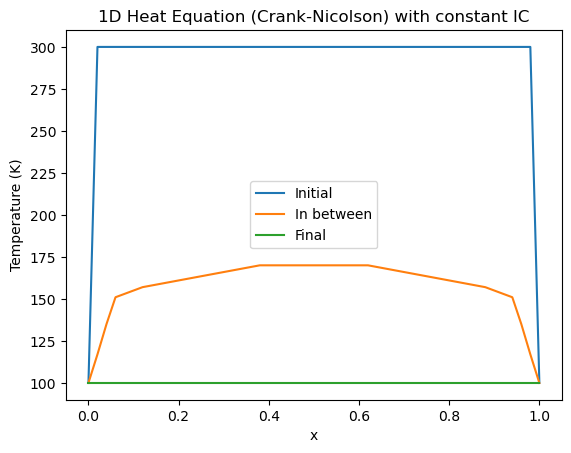

In [ ]:
plt.plot(x1, time_history1[0], label = "Initial")
plt.plot(x1, time_history1[len(time_history1)//2], label = "Intermediate")
plt.plot(x1, T, label = "Final")

plt.xlabel("x")
plt.ylabel("Temperature (K)")
plt.title("1D Heat Equation (Crank-Nicolson) with constant IC")
plt.legend()
plt.show()

**Analysis:**

The rod attains a steady temperature profile of 100 K (constant tmperature at which it is maintained at the left and right ends) after a long time.

If we inspect the temperature profile at some time in between, we see that the temperature of all regions has gone down from $T_{init}$ = 300 K and it is in the process of attaining a steady temperature profile.

## **Question 2:**

**Part (a) & Part (b): Physical Setup & Boundary Conditions**

Setting parameters and boundary conditions

In [52]:
# Parameters
Nx = 51
L = 1.0
dx = L/(Nx-1)
Nt = 10000
dt = 0.1
alpha = 1e-4
r = alpha*dt/dx**2

# Spatial grid
x2 = np.linspace(0, L, Nx)

# Boundary conditions
Tl2 = 200
Tr2 = 400

Generating the initial temperature profile (Gaussian)

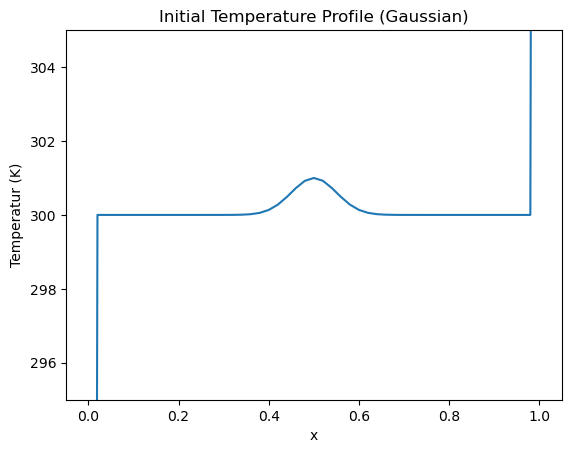

In [53]:
T = np.full(Nx, 300.0)
sigma = 0.05
mu = L/2

# Interior Points
gaussian_profile = np.exp(-(x2-mu)**2/(2*sigma**2))
T += gaussian_profile

# Boundary Points
T[0] = Tl2
T[-1] = Tr2
T_init = T.copy()

# Plotting the Initial profile
plt.plot(x2, T_init)
plt.xlabel("x")
plt.ylabel("Temperatur (K)")
plt.title("Initial Temperature Profile (Gaussian)")

plt.ylim(295, 305)
plt.show()

**Part (c)**

The Crank-Nicolson update for the interior points i = 1, 2,..., N-1:

$$
-\frac{r}{2}\,u_{i-1}^{n+1} 
\;+\;
\bigl(1 + r\bigr)\,u_i^{n+1}
\;-\;
\frac{r}{2}\,u_{i+1}^{n+1}
=
\frac{r}{2}\,u_{i-1}^n
\;+\;
\bigl(1 - r\bigr)\,u_i^n
\;+\;
\frac{r}{2}\,u_{i+1}^n.
$$

We denote
$$
u_i^n \approx u(x_i, t^n).
$$,

where $u_i^n$ is the temperature at time step n and position $x_i$ of the rod.

At i = 1,

$$
-\frac{r}{2}\,u_0^{n+1} 
\;+\;
\bigl(1 + r\bigr)\,u_1^{n+1}
\;-\;
\frac{r}{2}\,u_{2}^{n+1}
=
\frac{r}{2}\,u_{0}^n
\;+\;
\bigl(1 - r\bigr)\,u_0^n
\;+\;
\frac{r}{2}\,u_{2}^n.
$$

$$
\implies
(1+r)\,u_1^{n+1} - \frac{r}{2}\,u_2^{n+1} = (1-r)\,u_1^n + \frac{r}{2}\,u_2^n + ru_{left}
$$

since $u_0^n = u_{left}$

Similarly, at i = N-1:

$$
-\frac{r}{2}\,u_{N-2}^{n+1} 
\;+\;
\bigl(1 + r\bigr)\,u_{N-1}^{n+1}
\;-\;
\frac{r}{2}\,u_N^{n+1}
=
\frac{r}{2}\,u_{N-2}^n
\;+\;
\bigl(1 - r\bigr)\,u_{N-1}^n
\;+\;
\frac{r}{2}\,u_N^n.
$$

$$
\implies
-\frac{r}{2}\,u_{N-2}^{n+1} + (1+r)\,u_{N-1}^{n+1} = \frac{r}{2}\,u_{N-2}^n + (1-r)\,u_{N-1}^n + ru_{right}
$$

since $u_N^n = u_{right}$

This is how the boundary temperatures appear in the RHS

Forming the matrices A and B

In [40]:
# Interior points
n_interior = Nx-2

# Matrix A
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior, 1+r)
c_A = np.full(n_interior-1, -r/2)

# Matrix B
a_B = np.full(n_interior-1,  r/2)
b_B = np.full(n_interior,    1 - r)
c_B = np.full(n_interior-1,  r/2)

Solving the heat equation

In [ ]:
# Temperature profile over all time steps
time_history2 = [T_init]

# Solving the heat equation for all time steps
for n in range(Nt):
    T_old = T.copy()

    # We calculate only the interior points as the end point temperatures are fixed by boundary conditions
    T_in = T_old[1:-1]
    RHS = np.zeros(n_interior)      # B*T_in

    # Calculating B*T_in
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]

        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]
    
    # At the boundaries (i = 1 and i = N-1), we have to add r*Tl and r*Tr
    # since temperatures at boundaries at different time steps are fixed (Boundary Conditions)
    RHS[0] += r*Tl2
    RHS[-1] += r*Tr2

    # Implementing the Thomas SOlver and calculating T_new = temperature profile at next time step
    T_new = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())

    # Incorporating the new solution and boundary conditions
    T[1:-1] = T_new
    T[0] = Tl2
    T[-1] = Tr2
    
    # Recording the temperature profile
    time_history2.append(T.copy())

**Part (d): Results and steady state**

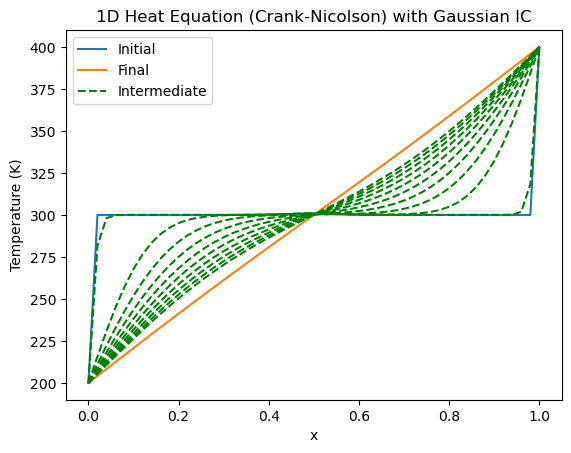

In [44]:
plt.plot(x2, time_history2[0], label = "Initial")
plt.plot(x2, T, label = "Final")

for n in range(9, Nt-5000, 500):
    if n == 9:
        plt.plot(x2, time_history2[n], 'g--', label = "Intermediate")
    else:
        plt.plot(x2, time_history2[n], 'g--')

plt.xlabel("x")
plt.ylabel("Temperature (K)")
plt.title("1D Heat Equation (Crank-Nicolson) with Gaussian IC")
plt.legend()
plt.show()

As can be seen from the graph, the temperature approaches a linear steady state from $T_{left}$ to $T_{right}$ over a long period of time

**Checking for covergence by changing parameters**

Defining functions for solving the heat equation

In [84]:
# Function for advancing 1 time step
def advance_time(T: np.ndarray, a_A, b_A, c_A, a_B, b_B, c_B):
    T_old = T.copy()
    n_interior = len(b_A)
    
    # We calculate only the interior points as the end point temperatures are fixed by boundary conditions
    T_in = T_old[1:-1]
    RHS = np.zeros(n_interior)      # B*T_in

    # Calculating B*T_in
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]

        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]
    
    # At the boundaries (i = 1 and i = N-1), we have to add r*Tl and r*Tr
    # since temperatures at boundaries at different time steps are fixed (Boundary Conditions)
    RHS[0] += r*Tl2
    RHS[-1] += r*Tr2

    # Implementing the Thomas SOlver and calculating T_new = temperature profile at next time step
    T_new = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())

    # Incorporating the new solution and boundary conditions
    T[1:-1] = T_new
    T[0] = Tl2
    T[-1] = Tr2

    return T

# Function for solving the heat equation by running through all time steps
def heat_solver(r, threshold, Nx, T_init: np.ndarray):
    n_interior = Nx-2

    # Matrix A
    a_A = np.full(n_interior-1, -r/2)
    b_A = np.full(n_interior, 1+r)
    c_A = np.full(n_interior-1, -r/2)

    # Matrix B
    a_B = np.full(n_interior-1,  r/2)
    b_B = np.full(n_interior,    1 - r)
    c_B = np.full(n_interior-1,  r/2)

    T = T_init.copy()
    T_old = np.zeros(Nx)
    steps = 0

    # Solving for temperature profile for all time steps till it converges
    while np.max(np.abs(T-T_old)) > threshold:
        T_old = T.copy()
        T = advance_time(T, a_A, b_A, c_A, a_B, b_B, c_B)
        steps += 1
    
    return T, steps

# Generating the initial temperature profile
def initial_profile(Nx):
    T = np.full(Nx, 300.0)
    sigma = 0.05
    mu = L/2

    # Spatial grid
    x = np.linspace(0, L, Nx)

    # Interior Points
    gaussian_profile = np.exp(-(x-mu)**2/(2*sigma**2))
    T += gaussian_profile

    # Boundary Points
    T[0] = Tl2
    T[-1] = Tr2

    return T


Changing $\triangle t$

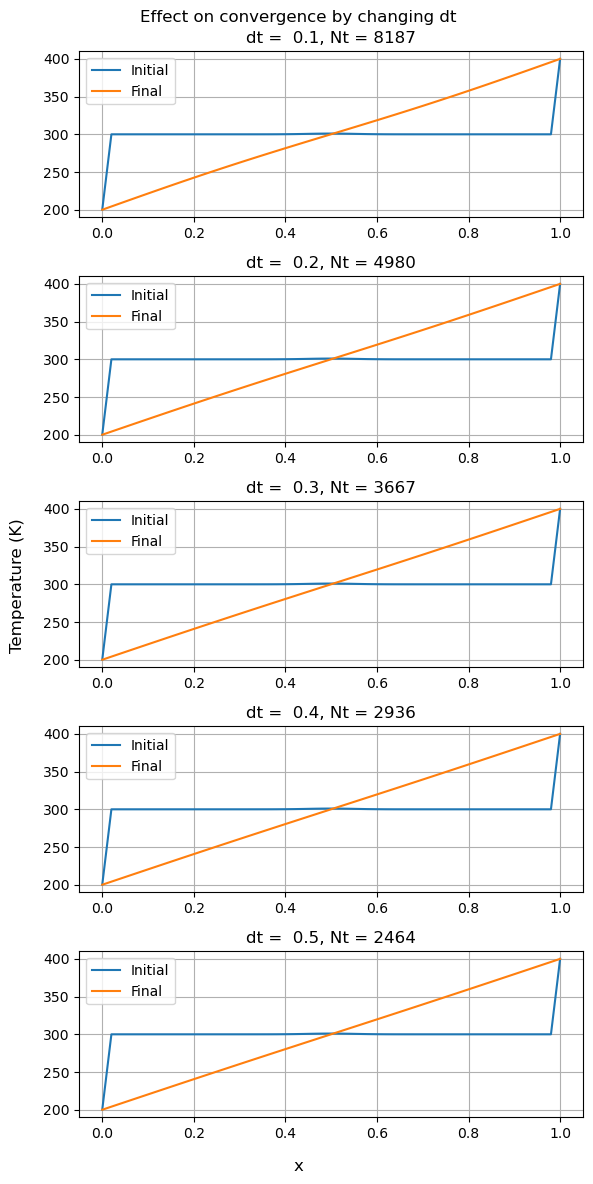

In [81]:
dts = np.linspace(0.1, 0.5, 5)
Nx = 51
dx = L/(Nx-1)
x = np.linspace(0, L, Nx)
threshold = 1e-3
T_init = initial_profile(Nx)

fig, ax = plt.subplots(5, 1, figsize = (6, 12))

for i in range(len(dts)):
    # Solving for different dt
    r = alpha*dts[i]/dx**2
    T, Nt = heat_solver(r, threshold, Nx, T_init)

    # Plotting
    ax[i].plot(x2, T_init, label = "Initial")
    ax[i].plot(x2, T, label = "Final")
    ax[i].set_title(f"dt = {dts[i]: 0.1f}, Nt = {Nt}")
    ax[i].legend()
    ax[i].grid()

fig.supxlabel("x")
fig.supylabel("Temperature (K)")
fig.suptitle("Effect on convergence by changing dt")

plt.tight_layout()
plt.show()


**Analysis:**

As can be seen from the graph, as dt $\uparrow$, $N_t \downarrow$, hence speed of convergence $\uparrow$ on $\uparrow$ dt. 

This is because r $\uparrow$ on $\uparrow$ dt, hence diffusion rate increases. Lesser time steps are required for reaching steady state.

Changing $\triangle x$

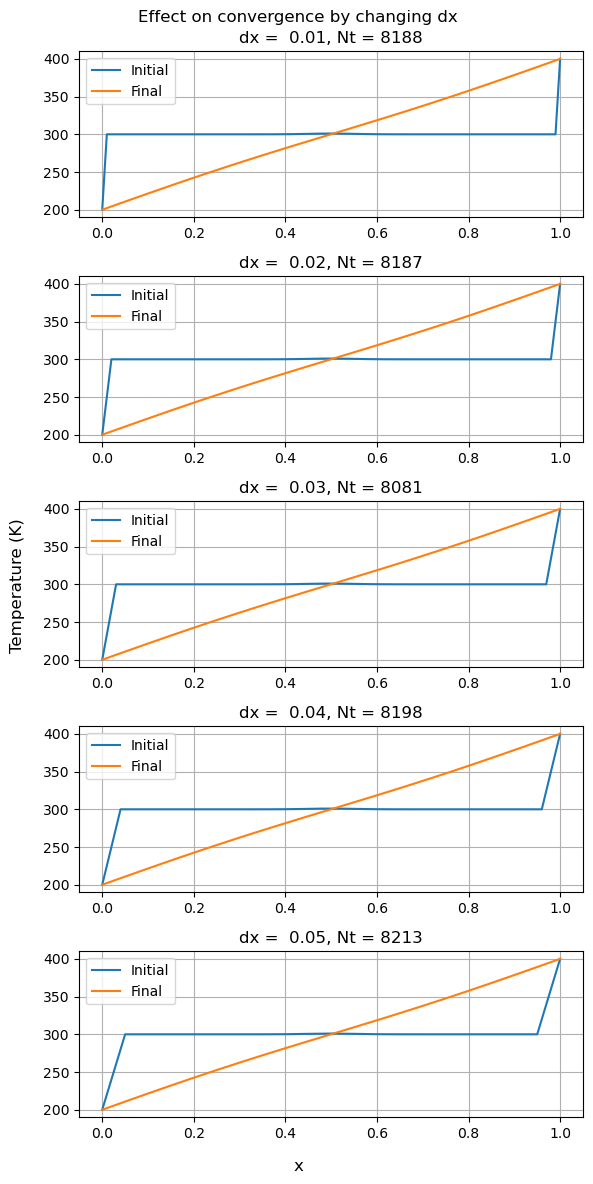

In [89]:
dxs = np.linspace(1e-2, 5e-2, 5)
Nxs = np.array([int(L/dx) + 1 for dx in dxs])
threshold = 1e-3
dt = 0.1

fig, ax = plt.subplots(5, 1, figsize = (6, 12))

for i in range(len(dxs)):
    Nx = Nxs[i]
    dx = dxs[i]

    # Parameters for different dx
    r = alpha*dt/dx**2
    x = np.linspace(0, L, Nx)   # Spatial grid
    T_init = initial_profile(Nx)    # Initial temperature profile

    # Solving
    T, Nt = heat_solver(r, threshold, Nx, T_init)

    # Plotting
    ax[i].plot(x, T_init, label = "Initial")
    ax[i].plot(x, T, label = "Final")
    ax[i].set_title(f"dx = {dx: 0.2f}, Nt = {Nt}")
    ax[i].legend()
    ax[i].grid()

fig.supxlabel("x")
fig.supylabel("Temperature (K)")
fig.suptitle("Effect on convergence by changing dx")

plt.tight_layout()
plt.show()

**Analysis:**

As can be seen, $N_t \uparrow$ as dx $\uparrow$. Hence, the convergence speed $\downarrow$ as dx $\uparrow$. 

This is because r $\downarrow$ on $\uparrow$ dx and hence diffusion per step decreases. More steps are required for reaching steady state.

Changing $\alpha$

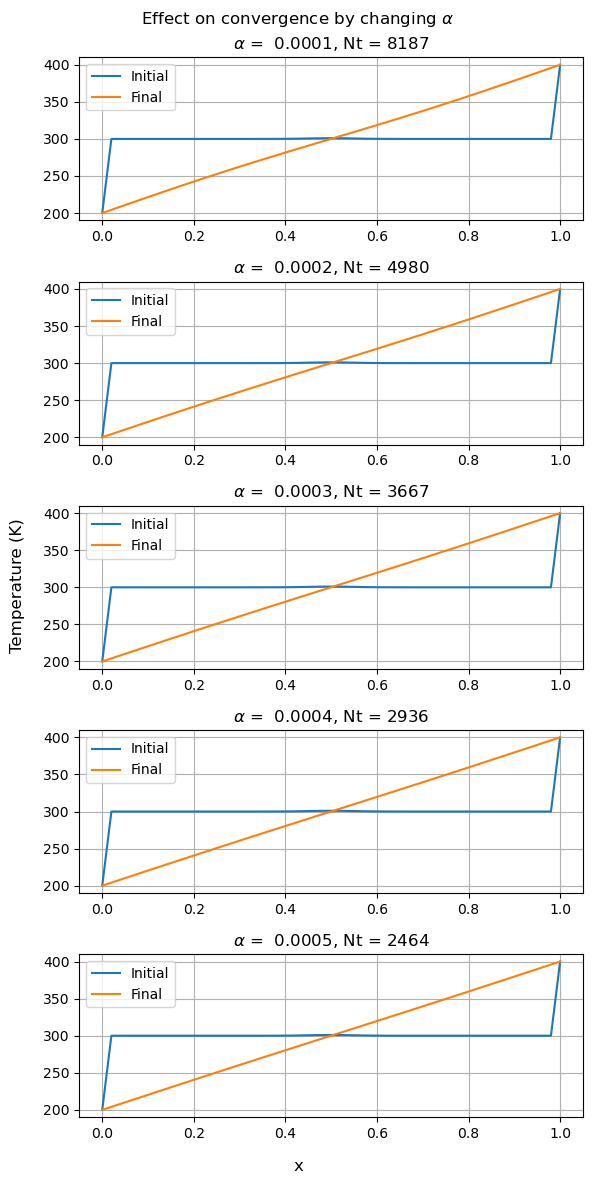

In [90]:
alphas = np.linspace(1e-4, 5e-4, 5)
dt = 0.1
Nx = 51
dx = L/(Nx-1)
x = np.linspace(0, L, Nx)
threshold = 1e-3
T_init = initial_profile(Nx)

fig, ax = plt.subplots(5, 1, figsize = (6, 12))

for i in range(len(alphas)):
    alpha = alphas[i]
    # Solving for different dt
    r = alpha*dt/dx**2
    T, Nt = heat_solver(r, threshold, Nx, T_init)

    # Plotting
    ax[i].plot(x2, T_init, label = "Initial")
    ax[i].plot(x2, T, label = "Final")
    ax[i].set_title(f"$\\alpha$ = {alpha: 0.4f}, Nt = {Nt}")
    ax[i].legend()
    ax[i].grid()

fig.supxlabel("x")
fig.supylabel("Temperature (K)")
fig.suptitle("Effect on convergence by changing $\\alpha$")

plt.tight_layout()
plt.show()

**Analysis:**

As can be seen, as $\alpha \uparrow$, $N_t \downarrow$. Hence the speed of convergence $\uparrow$ as $\alpha \uparrow$.

This is because r $\uparrow$ on $\uparrow \alpha$, hence diffusion rate increases. Lesser time steps are required for achieving steady state. 